# MLP Classification on the MNIST Dataset

In this example, we demonstrate how to:

- Load and preprocess the MNIST dataset
- Implement a Multi-Layer Perceptron (MLP) from scratch using NumPy
- Train an MLP for multiclass digit classification (0–9)
- Evaluate the model using classification accuracy
- Visualize learned features (e.g., first-layer weights) and discuss why MLPs outperform linear models on image data

---

## Example: MNIST Dataset

### Overview

The **MNIST dataset** consists of **handwritten digits from 0 to 9**, where each digit is represented as a **28 × 28 grayscale image**.  
Each image is flattened into a 784-dimensional feature vector for use in standard machine learning algorithms.

---

### Data source (Kaggle):
https://www.kaggle.com/datasets/hojjatk/mnist-dataset

---

### Dataset Content

The MNIST dataset contains a total of **70,000 labeled images**, split into:

- **Training set:** 60,000 examples  
- **Test set:** 10,000 examples  

Each sample consists of:

- **Input:** a 28 × 28 grayscale image of a handwritten digit  
- **Label:** an integer in {0, 1, ..., 9}

In the CSV files:

- The **first column** is the digit label  
- The remaining **784 columns** correspond to pixel intensity values (0–255)

---

### Preprocessing

Before training the model, the data is preprocessed as follows:

- Each image is flattened into a vector of length 784
- Pixel values are normalized to the range **[0, 1]** by dividing by 255
- Labels are kept as integers in {0, 1, ..., 9} for multiclass classification

---

### Learning Task and Output

The learning task is a **supervised multiclass classification problem**:

> Given an input image of a handwritten digit, predict which digit (0–9) it represents.

In this notebook:

- The **input** is a normalized 784-dimensional feature vector
- The **MLP model** produces class scores for digits 0–9 via hidden-layer nonlinear transformations
- The **output** is a predicted class label in {0, 1, ..., 9} (selected by `argmax` over the output scores)
- The model is evaluated using **classification accuracy** on the test set

An MLP improves over a linear Perceptron by introducing **nonlinear hidden layers**, allowing it to learn more expressive decision boundaries and achieve higher accuracy on MNIST.


In [7]:
from perceptron import PerceptronBinary, PerceptronOVR

In [8]:
import pandas as pd
import numpy as np

train_df = pd.read_csv("mnist_train.csv", header= 0)
test_df  = pd.read_csv("mnist_test.csv", header= 0)

y_train = train_df.iloc[:, 0].values     
X_train = train_df.iloc[:, 1:].values    

y_test = test_df.iloc[:, 0].values          
X_test = test_df.iloc[:, 1:].values         

X_train = X_train.astype(np.float32) / 255.0
X_test  = X_test.astype(np.float32) / 255.0


In [9]:
print(train_df.shape)
print(test_df.shape)


(60000, 785)
(10000, 785)


In [10]:
# filter 0 & 1
train_mask = (y_train == 0) | (y_train == 1)
test_mask  = (y_test  == 0) | (y_test  == 1)

X_train_bin = X_train[train_mask]
y_train_bin = y_train[train_mask]
X_test_bin  = X_test[test_mask]
y_test_bin  = y_test[test_mask]

# mapping {0,1} to {-1, +1}
y_train_bin = np.where(y_train_bin == 1, 1, -1)
y_test_bin  = np.where(y_test_bin  == 1, 1, -1)


In [11]:
from mlp import SimpleMLP

In [12]:
# MLP
mlp = SimpleMLP(
    input_dim=784,
    hidden_dim=512,   
    output_dim=10,
    lr=0.005,
    momentum=0.9
)

mlp.train(X_train, y_train, epochs=10, batch_size=64)

# evaluate on test set
y_pred = mlp.predict(X_test)
test_acc = (y_pred == y_test).mean()
print("Test accuracy:", test_acc)


Epoch 1/10 - Train accuracy: 0.9106
Epoch 2/10 - Train accuracy: 0.9215
Epoch 3/10 - Train accuracy: 0.9296
Epoch 4/10 - Train accuracy: 0.9355
Epoch 5/10 - Train accuracy: 0.9432
Epoch 6/10 - Train accuracy: 0.9485
Epoch 7/10 - Train accuracy: 0.9545
Epoch 8/10 - Train accuracy: 0.9579
Epoch 9/10 - Train accuracy: 0.9613
Epoch 10/10 - Train accuracy: 0.9643
Test accuracy: 0.96


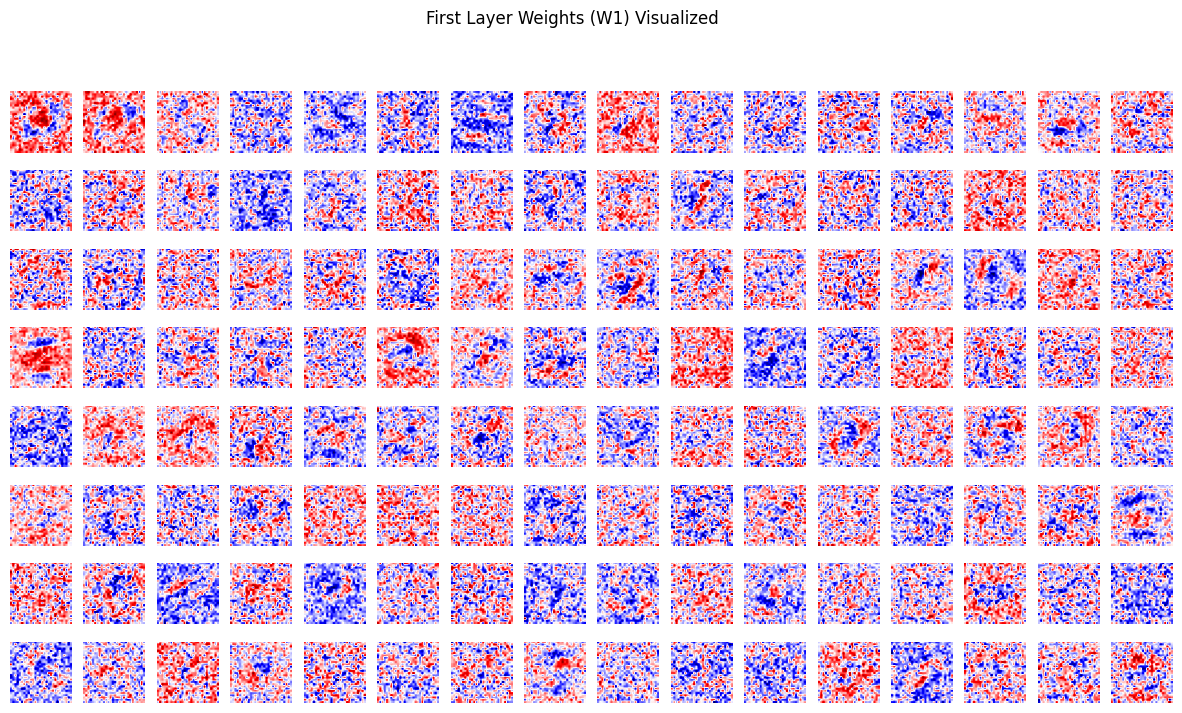

In [13]:
#visualization 
import matplotlib.pyplot as plt

W1 = mlp.W1   # shape (784, 128)

fig, axes = plt.subplots(8, 16, figsize=(15, 8))
axes = axes.ravel()

for i in range(128):
    weight_img = W1[:, i].reshape(28, 28)
    axes[i].imshow(weight_img, cmap='seismic')
    axes[i].axis('off')

plt.suptitle("First Layer Weights (W1) Visualized")
plt.show()


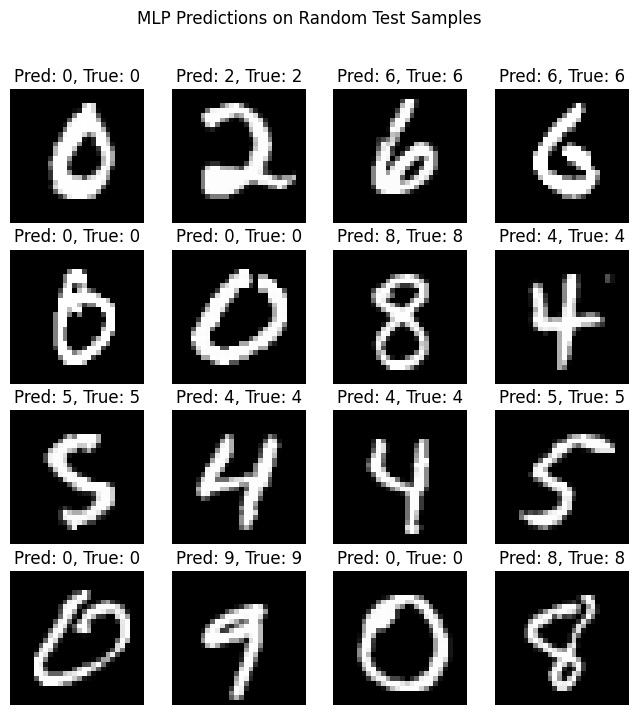

In [14]:
import numpy as np
import matplotlib.pyplot as plt

idx = np.random.choice(len(X_test), 16, replace=False)
images = X_test[idx]
labels = y_test[idx]
preds = mlp.predict(images)

fig, axes = plt.subplots(4, 4, figsize=(8, 8))

for i, ax in enumerate(axes.ravel()):
    ax.imshow(images[i].reshape(28, 28), cmap='gray')
    ax.set_title(f"Pred: {preds[i]}, True: {labels[i]}")
    ax.axis('off')

plt.suptitle("MLP Predictions on Random Test Samples")
plt.show()


## Interpretations & Conclusions

### Model Performance

The Multi-Layer Perceptron (MLP) achieves a **test accuracy of approximately 96%** on the MNIST handwritten digit classification task.  
This represents an improvement over the earlier baseline MLP models (≈ 92%), indicating that the current architecture and training choices are more effective at capturing the underlying structure of the data.

The performance gain can be attributed to:

- Compared to single-layer Perceptron, the introduction of **nonlinear hidden layers**, which allows the model to learn complex decision boundaries that are not linearly separable.
- Replacing **ReLU with the `tanh` activation function**, which provides smoother gradients and symmetric activations around zero. This often leads to more stable optimization and improved feature learning for MNIST.
- The use of **momentum** in gradient updates, which helps accelerate convergence and reduce oscillations during training.

---

### What we can see from visualization

Visualization of the **first-layer weight matrix** shows that the MLP learns structured, stroke-like patterns resembling digit components such as edges, curves, and intersections.  
This suggests that the hidden layer successfully extracts meaningful low-level visual features from raw pixel inputs, rather than relying on simple linear combinations.

Such representations are not achievable with a single-layer Perceptron and highlight the power gained by introducing hidden layers and nonlinear activations.

---

### Limitations

Despite the strong performance, several limitations remain:

- **Fully connected architecture**: The MLP operates on flattened input vectors, which removes the two-dimensional spatial structure of the original 28×28 images. As a result, the model treats all pixels as independent features and has no explicit notion of spatial locality or neighborhood relationships. This forces the network to relearn the same local patterns (e.g., edges or strokes) at different positions using separate parameters, leading to inefficient use of model capacity and limiting generalization compared to architectures that explicitly exploit spatial structure, such as convolutional neural networks.

- **Performance ceiling**: While 96% accuracy is strong, it is still below state-of-the-art MNIST results (often >99%).

- **Hyperparameter sensitivity**: The performance of the MLP is highly sensitive to the choice of hyperparameters, including learning rate, hidden layer size, batch size, activation function, and optimization settings. These parameters interact in nontrivial ways: changing one often requires retuning others to maintain stable training. As a result, suboptimal hyperparameter choices can lead to slow convergence, unstable optimization, or poor generalization, making systematic tuning an essential but nontrivial part of deploying MLPs in practice.

- **No uncertainty estimation**: The model outputs only class labels and does not provide calibrated probabilities or confidence measures.

---

### Potential Improvements

Several extensions could further improve performance and robustness:

- **Deeper networks** with multiple hidden layers to capture higher-level abstractions.
- **Alternative activation functions** such as Leaky ReLU or GELU to balance smooth gradients with sparsity.
- **Regularization techniques** including dropout or L2 regularization to mitigate overfitting.
- **Convolutional Neural Networks (CNNs)** to directly exploit spatial locality in image data.
- **Learning rate schedules or adaptive optimizers** to improve training stability and convergence.

---

### Conclusion

Overall, the MLP demonstrates that introducing nonlinear hidden layers and improved activation functions significantly enhances performance over linear models on the MNIST dataset.  
The improvement from approximately **92% to 96% test accuracy** illustrates the importance of architectural and optimization choices in neural network design.  
While the current model already learns meaningful visual features, it naturally motivates the use of more advanced architectures for further gains in accuracy and generalization.
